In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time
from torchinfo import summary

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Load data
train = pd.read_csv('TF_TS_train.csv')
test = pd.read_csv('TF_TS_test.csv')
valid = pd.read_csv('TF_TS_valid.csv')

# Interpolate the NaN values
train['TS'] = train['TS'].interpolate()
test['TS'] = test['TS'].interpolate()
valid['TS'] = valid['TS'].interpolate()

# Function to find rows with NaN values in a pandas DataFrame
def check_nans_in_dataframe(df, column_name, name):
    nan_rows = df[df[column_name].isna()]
    if not nan_rows.empty:
        print(f"Rows with NaN values in {name} dataset:")
        print(nan_rows)
    else:
        print(f"No NaN values in {name} dataset.")

# Check for NaN values in each dataset
check_nans_in_dataframe(train, 'TS', 'Train')
check_nans_in_dataframe(test, 'TS', 'Test')
check_nans_in_dataframe(valid, 'TS', 'Validation')

No NaN values in Train dataset.
No NaN values in Test dataset.
No NaN values in Validation dataset.


In [5]:
# Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data = scaler.fit_transform(train)
test_data = scaler.transform(test)
valid_data = scaler.transform(valid)

# Create sequences
def create_sequences(data, lookback=10):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])  # Use the last 'lookback' time steps for prediction
        y.append(data[i])  # The next time step is the target
    return np.array(X), np.array(y)

timesteps = 10
Xtrain, Ytrain = create_sequences(train_data, lookback=timesteps)
Xtest, Ytest = create_sequences(test_data, lookback=timesteps)
Xvalid, Yvalid = create_sequences(valid_data, lookback=timesteps)

# Convert to PyTorch tensors
Xtrain_tensor = torch.tensor(Xtrain, dtype=torch.float32).to(device)
Ytrain_tensor = torch.tensor(Ytrain, dtype=torch.float32).to(device)
Xtest_tensor = torch.tensor(Xtest, dtype=torch.float32).to(device)
Ytest_tensor = torch.tensor(Ytest, dtype=torch.float32).to(device)
Xvalid_tensor = torch.tensor(Xvalid, dtype=torch.float32).to(device)
Yvalid_tensor = torch.tensor(Yvalid, dtype=torch.float32).to(device)

print(
    f"""Xtrain, Ytrain: {Xtrain_tensor.shape}, {Ytrain_tensor.shape}
Xtest,   Ytest: {Xtrain_tensor.shape}, {Ytrain_tensor.shape}
Xvalid, Yvalid: {Xvalid_tensor.shape}, {Yvalid_tensor.shape}"""
)

Xtrain, Ytrain: torch.Size([340060, 10, 2]), torch.Size([340060, 2])
Xtest,   Ytest: torch.Size([340060, 10, 2]), torch.Size([340060, 2])
Xvalid, Yvalid: torch.Size([170025, 10, 2]), torch.Size([170025, 2])


In [7]:
# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.lstm3 = nn.LSTM(hidden_size2, hidden_size3, batch_first=True)
        self.fc = nn.Linear(hidden_size3, output_size)
    
    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        out, _ = self.lstm3(out)
        out = self.fc(out[:, -1, :])  # Use the output of the last time step
        return out

In [9]:
# Instantiate the model
batch_size = 512
model = LSTMModel(input_size=2, hidden_size1=96, hidden_size2=16, hidden_size3=48, output_size=2).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.000023)

summary(model, input_size=(batch_size, timesteps, 2), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [512, 2]                  --
├─LSTM: 1-1                              [512, 10, 96]             38,400
├─LSTM: 1-2                              [512, 10, 16]             7,296
├─LSTM: 1-3                              [512, 10, 48]             12,672
├─Linear: 1-4                            [512, 2]                  98
Total params: 58,466
Trainable params: 58,466
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 298.89
Input size (MB): 0.04
Forward/backward pass size (MB): 6.56
Params size (MB): 0.23
Estimated Total Size (MB): 6.84

Epoch 1/50, Train Loss: 0.0221, Val Loss: 0.0190
Epoch 2/50, Train Loss: 0.0212, Val Loss: 0.0178
Epoch 3/50, Train Loss: 0.0194, Val Loss: 0.0154
Epoch 4/50, Train Loss: 0.0158, Val Loss: 0.0115
Epoch 5/50, Train Loss: 0.0118, Val Loss: 0.0095
Epoch 6/50, Train Loss: 0.0107, Val Loss: 0.0093
Epoch 7/50, Train Loss: 0.0104, Val Loss: 0.0091
Epoch 8/50, Train Loss: 0.0102, Val Loss: 0.0089
Epoch 9/50, Train Loss: 0.0099, Val Loss: 0.0087
Epoch 10/50, Train Loss: 0.0096, Val Loss: 0.0084
Epoch 11/50, Train Loss: 0.0091, Val Loss: 0.0078
Epoch 12/50, Train Loss: 0.0082, Val Loss: 0.0067
Epoch 13/50, Train Loss: 0.0064, Val Loss: 0.0043
Epoch 14/50, Train Loss: 0.0036, Val Loss: 0.0016
Epoch 15/50, Train Loss: 0.0017, Val Loss: 0.0010
Epoch 16/50, Train Loss: 0.0010, Val Loss: 0.0011
Epoch 17/50, Train Loss: 0.0007, Val Loss: 0.0010
Epoch 18/50, Train Loss: 0.0005, Val Loss: 0.0008
Epoch 19/50, Train Loss: 0.0004, Val Loss: 0.0007
Epoch 20/50, Train Loss: 0.0003, Val Loss: 0.0006
Epoch 21/

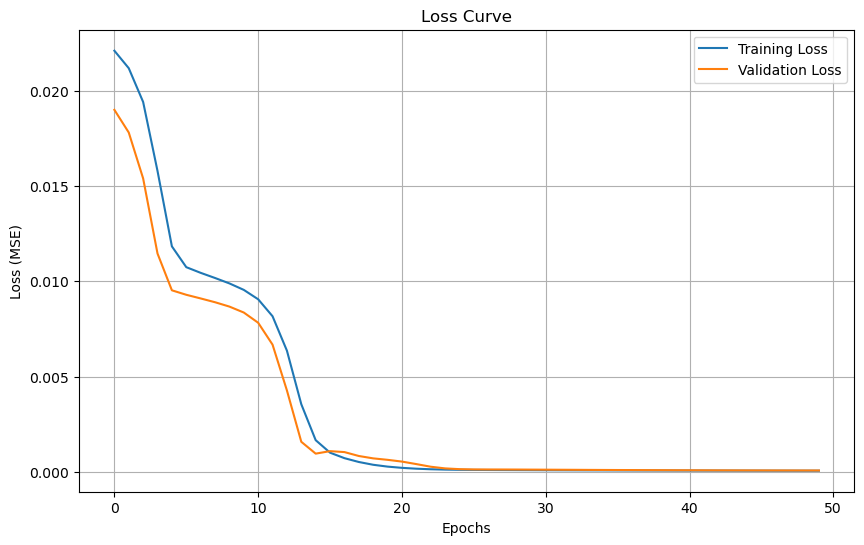

In [19]:
# Training loop
epochs = 50
train_dataset = torch.utils.data.TensorDataset(Xtrain_tensor, Ytrain_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

valid_dataset = torch.utils.data.TensorDataset(Xvalid_tensor, Yvalid_tensor)
valid_loader  = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

start = time.time()

history = {'loss': [], 'val_loss': []}
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    #scheduler.step()
    history['loss'].append(epoch_loss / len(train_loader))
    loss = epoch_loss / len(train_loader)
    
    # Validation loss
    model.eval()
    val_loss_accum = 0.0
    with torch.no_grad():
        for Xv_batch, Yv_batch in valid_loader:
            Xv_batch = Xv_batch.to(device)
            Yv_batch = Yv_batch.to(device)

            val_out = model(Xv_batch)
            batch_val_loss = criterion(val_out, Yv_batch)
            val_loss_accum += batch_val_loss.item()

    avg_val_loss = val_loss_accum / len(valid_loader)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss:.4f}, Val Loss: {avg_val_loss:.4f}")


end = time.time()
print(f"Training took {end - start}s")

# Plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title(f"Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid()
plt.show()

Inference took: 2.9827s


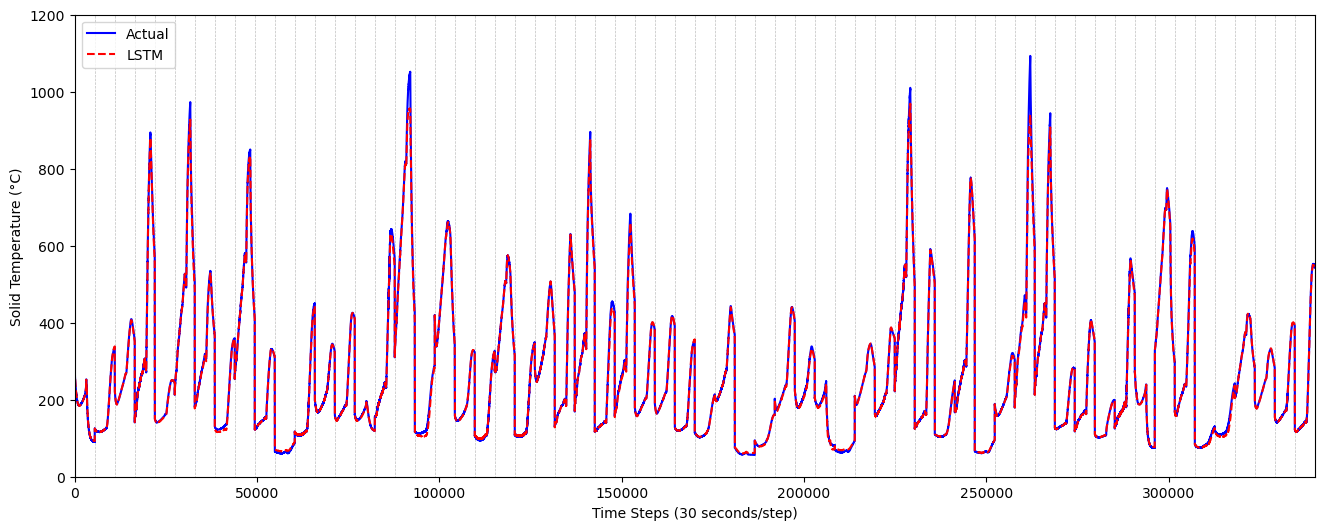

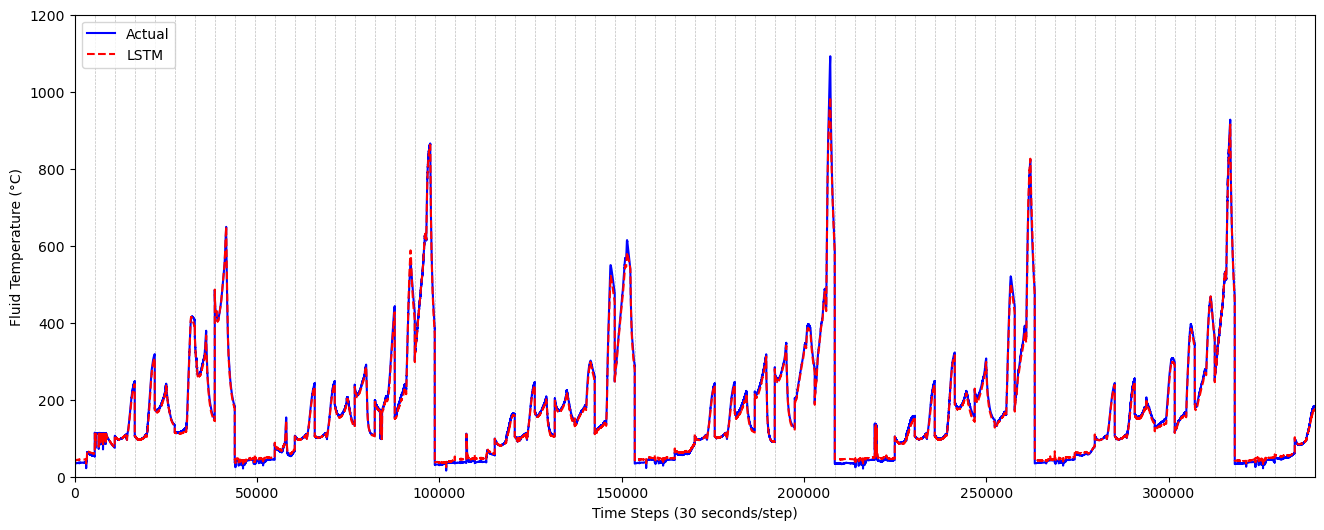

In [31]:
test_dataset = torch.utils.data.TensorDataset(Xtest_tensor, Ytest_tensor)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 2) Run a small loop over test batches to collect predictions and compute test loss
model.eval()
test_loss_accum = 0.0
all_preds = []
all_trues = []

start = time.time()
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)

        # Compute batch loss (e.g. MSE)
        loss = criterion(outputs, Y_batch)
        test_loss_accum += loss.item()

        # Store predictions and true values (move back to CPU)
        all_preds.append(outputs.cpu())
        all_trues.append(Y_batch.cpu())
        
# 4) Concatenate all batch‐wise tensors into single tensors
all_preds = torch.cat(all_preds, dim=0)  # shape: (num_test_samples, ...)
all_trues = torch.cat(all_trues, dim=0)

# Convert to NumPy for plotting
Ypred = all_preds.cpu().numpy()
Ytrue = all_trues.cpu().numpy()

# Rescale predictions and true values back to their original scale
Ypred_rescaled = scaler.inverse_transform(Ypred)
Ytrue_rescaled = scaler.inverse_transform(Ytrue)

end = time.time()
print(f"Inference took: {end-start:.4f}s")

# Save the rescaled arrays as .npy files
# np.save('Ytrue_rescaled.npy', Ytrue_rescaled)
# np.save('Ypred_rescaled.npy', Ypred_rescaled)

# Extract individual outputs for evaluation
Ypred_1, Ypred_2 = Ypred_rescaled[:, 0], Ypred_rescaled[:, 1]
Ytrue_1, Ytrue_2 = Ytrue_rescaled[:, 0], Ytrue_rescaled[:, 1]

# Plot first output
plt.figure(figsize=(16, 6))

# Add vertical lines every 5485 time steps in the main plot
for x_val in np.arange(5485, 340070, 5485):
    plt.vlines(x=x_val, ymin=-100, ymax=1500, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
plt.plot(Ytrue_1, 'b', label="Actual")
plt.plot(Ypred_1, label="LSTM", color='r', linestyle='dashed')
plt.xlabel('Time Steps (30 seconds/step)')
plt.ylabel('Solid Temperature (°C)')
plt.ylim(0, 1200)
plt.xlim(0, 340070)
plt.legend(loc='upper left')
plt.show()

# Plot second output
plt.figure(figsize=(16, 6))

# Add vertical lines every 5485 time steps in the main plot
for x_val in np.arange(5485, 340070, 5485):
    plt.vlines(x=x_val, ymin=-100, ymax=1500, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.plot(Ytrue_2, 'b',label="Actual")
plt.plot(Ypred_2, label="LSTM", color='r', linestyle='dashed')
plt.xlabel('Time Steps (30 seconds/step)')
plt.ylabel('Fluid Temperature (°C)')
plt.ylim(0, 1200)
plt.xlim(0, 340070)
plt.legend(loc='upper left')
plt.show()

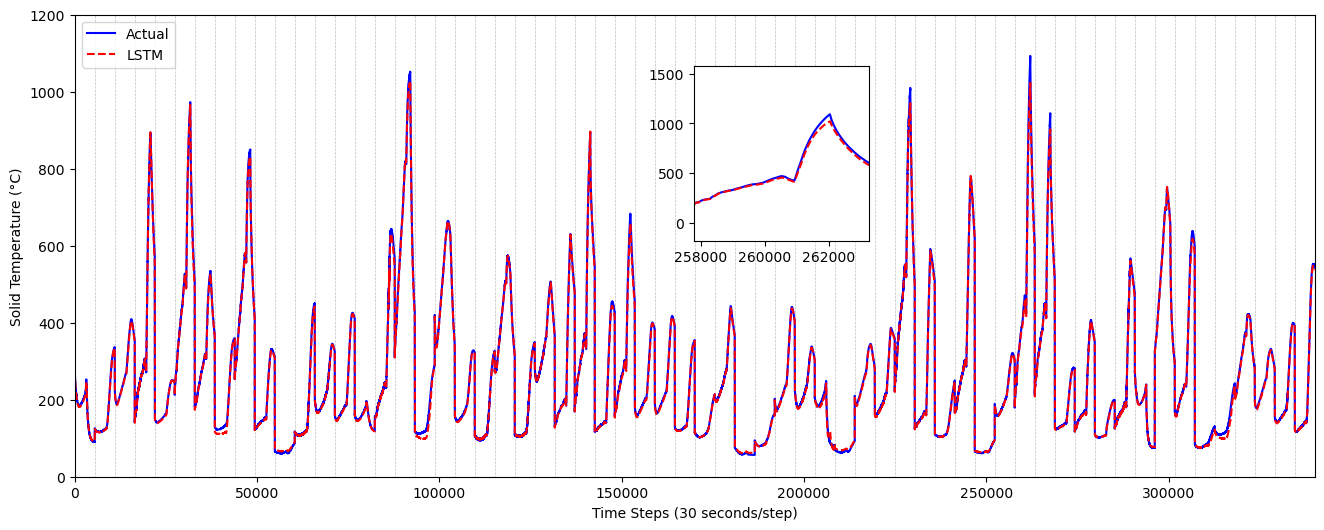

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Define the x-range for the inset
sensor_range_i = 257795
sensor_range_f = sensor_range_i + 5473

# Create the figure and main axes
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(Ytrue_1))  # assuming Ytrue_1 and Ypred_1 have the same length

# Add vertical lines every 5485 time steps in the main plot
for x_val in np.arange(5485, 340070, 5485):
    ax.vlines(x=x_val, ymin=-100, ymax=1500, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Plot the main data
ax.plot(Ytrue_1, 'b', label="Actual")
ax.plot(Ypred_1, label="LSTM", color='r', linestyle='dashed')
ax.set_xlabel('Time Steps (30 seconds/step)')
ax.set_ylabel('Solid Temperature (°C)')
ax.set_ylim(0, 1200)
ax.set_xlim(0, 340070)
leg = ax.legend(loc='upper left')

# Create an inset axis using the same bbox settings as before
axins = inset_axes(ax,
                   width=1.75, height=1.75, 
                   bbox_to_anchor=(0.52, 0.65, 0.1, 0.1),  # adjust as needed,
                   bbox_transform=ax.transAxes,
                   loc='center')

# Create a mask for the desired x-range for the inset plot
mask = (x >= sensor_range_i) & (x <= sensor_range_f)

# Re-plot the same data on the inset for the zoomed region
axins.plot(x[mask], Ytrue_1[mask], 'b')
axins.plot(x[mask], Ypred_1[mask], color='r', linestyle='dashed')
# Optionally, add vertical lines to the inset if they fall within the range
for x_val in np.arange(5485, 340070, 5485):
    if sensor_range_i <= x_val <= sensor_range_f:
        axins.vlines(x=x_val, ymin=-100, ymax=1500, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Set the x-limits of the inset to zoom in to the desired region
axins.set_xlim(sensor_range_i, sensor_range_f)
# Optionally, adjust y-limits on the inset if needed, e.g.:
# axins.set_ylim(lower_bound, upper_bound)
fig.savefig('DETERM_TS.png', dpi=300, bbox_inches='tight', bbox_extra_artists=[axins, leg])
plt.show()

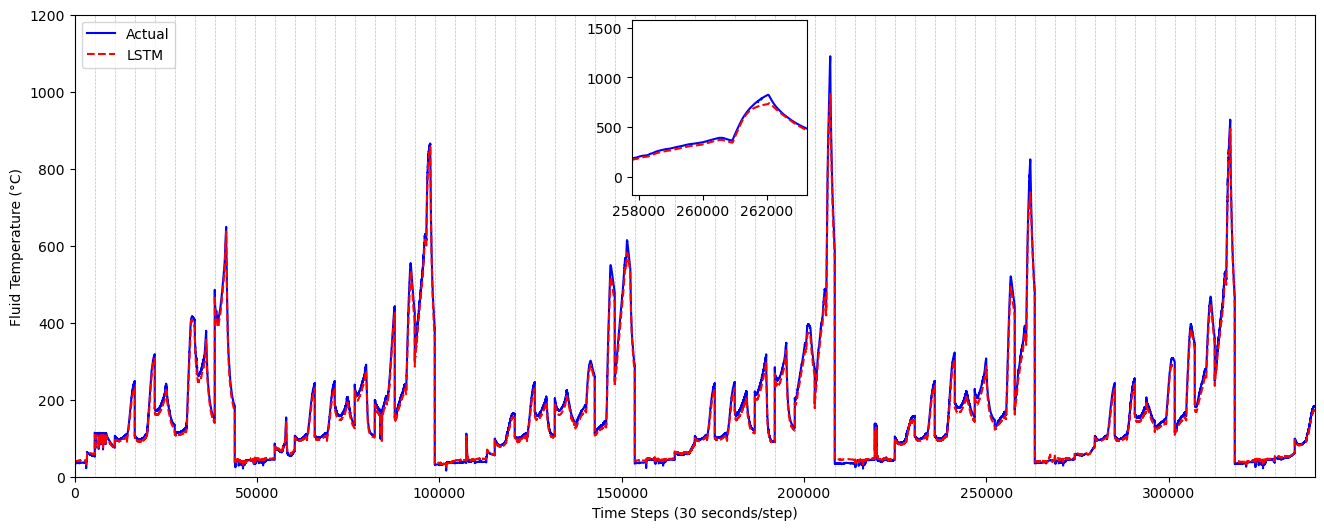

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Define the sensor range for the inset
sensor_range_i = 257795
sensor_range_f = sensor_range_i + 5473

# Create the figure and main axes for the second output
fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(Ytrue_2))  # Assuming Ytrue_2 and Ypred_2 have the same length

# Add vertical lines every 5485 time steps in the main plot
for x_val in np.arange(5485, 340070, 5485):
    ax.vlines(x=x_val, ymin=-100, ymax=1500, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Plot the main data for the second output
ax.plot(Ytrue_2, 'b', label="Actual")
ax.plot(Ypred_2, label="LSTM", color='r', linestyle='dashed')
ax.set_xlabel('Time Steps (30 seconds/step)')
ax.set_ylabel('Fluid Temperature (°C)')
ax.set_ylim(0, 1200)
ax.set_xlim(0, 340070)
leg = ax.legend(loc='upper left')

# Create an inset axis using the same positioning parameters as before
axins = inset_axes(ax,
                   width=1.75, height=1.75, 
                   bbox_to_anchor=(0.47, 0.75, 0.1, 0.1),
                   bbox_transform=ax.transAxes,
                   loc='center')

# Create a mask for the desired x-range for the inset plot
mask = (x >= sensor_range_i) & (x <= sensor_range_f)

# Re-plot the same data on the inset for the zoomed region
axins.plot(x[mask], Ytrue_2[mask], 'b')
axins.plot(x[mask], Ypred_2[mask], color='r', linestyle='dashed')
# Optionally add vertical lines in the inset if they fall within the range
for x_val in np.arange(5485, 340070, 5485):
    if sensor_range_i <= x_val <= sensor_range_f:
        axins.vlines(x=x_val, ymin=-100, ymax=1500, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Set the x-limits of the inset to zoom into the desired region
axins.set_xlim(sensor_range_i, sensor_range_f)
fig.savefig('DETERM_TF.png', dpi=300, bbox_inches='tight', bbox_extra_artists=[axins, leg])
plt.show()

In [25]:
# Calculate metrics
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true)**2)) * 100
    return r2, mae, mape, rmse, rmspe

r2, mae, mape, rmse, rmspe = calculate_metrics(Ytrue_1, Ypred_1)
print(f"R^2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"RMSE: {rmse}")
print(f"RMSPE: {rmspe}%")
print()
r2, mae, mape, rmse, rmspe = calculate_metrics(Ytrue_2, Ypred_2)
print(f"R^2 Score: {r2}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}%")
print(f"RMSE: {rmse}")
print(f"RMSPE: {rmspe}%")

R^2 Score: 0.9962558538050319
MAE: 3.690319776535034
MAPE: 1.6514455899596214%
RMSE: 11.312175750732422
RMSPE: 7.215872406959534%

R^2 Score: 0.996102836144583
MAE: 6.036617279052734
MAPE: 6.550876051187515%
RMSE: 9.431683540344238
RMSPE: 15.067712962627411%
